У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('./data/time-series/train.csv')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
display(data.head())

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [6]:
monthly_data = (
    data
    .groupby('store')['sales']
    .resample('M')
    .mean()
    .reset_index()
)

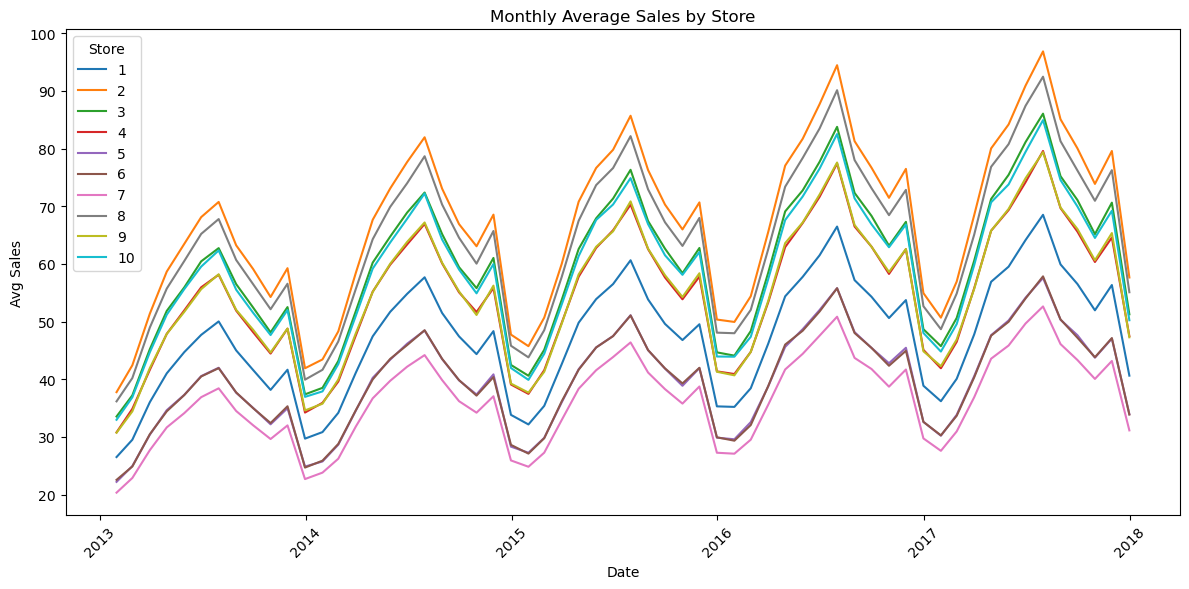

In [7]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_data,
    x='date',
    y='sales',
    hue='store',
    palette='tab10'
)

plt.title('Monthly Average Sales by Store')
plt.xlabel('Date')
plt.ylabel('Avg Sales')
plt.xticks(rotation=45)

plt.legend(title='Store')
plt.tight_layout()
plt.show()

Усі магазини демонструють майже ідентичну динаміку продажів із чітко вираженою сезонністю та зростаючим трендом, при цьому лінії продажів показують стабільну різницю між магазинами.

Це означає, що основна відмінність між магазинами полягає в їхньому базовому рівні продажів.

Подивимось на динаміку продажів по кожному item окремо з відображенням min, max та mean значень

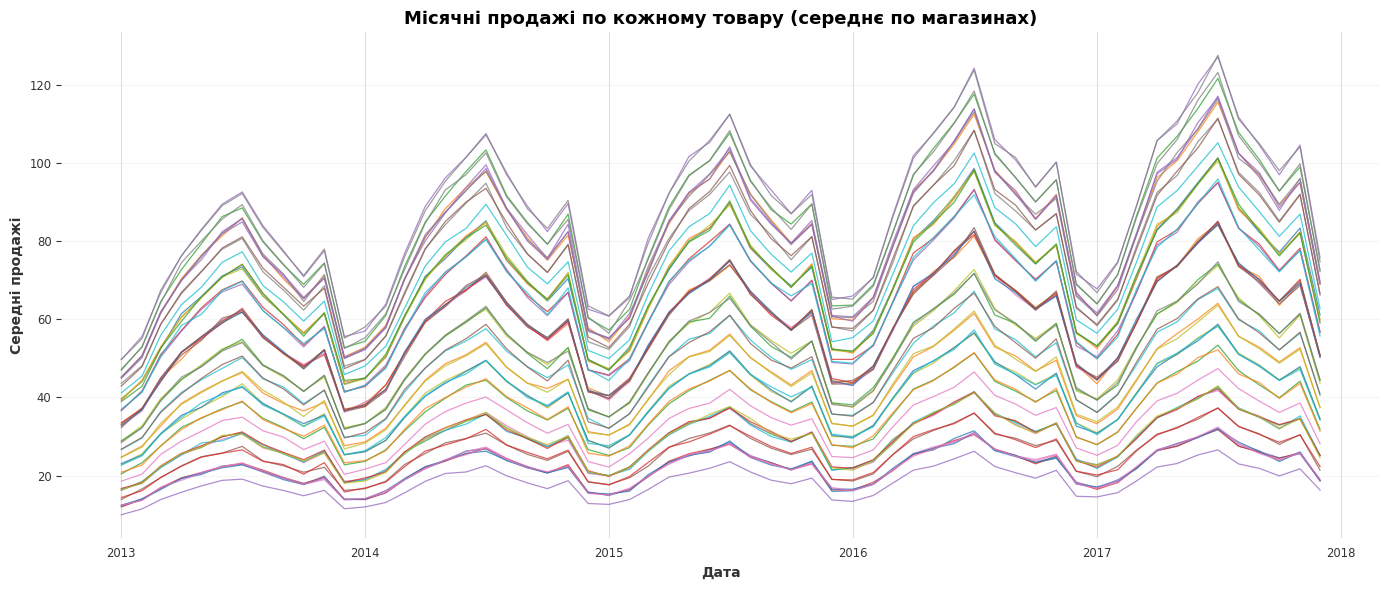

In [99]:
import matplotlib.dates as mdates

monthly = (data.groupby([data.index.to_period('M'), 'item'])['sales']
             .mean()
             .unstack('item'))
monthly.index = monthly.index.to_timestamp()

colors = sns.color_palette('tab10', len(monthly.columns))

fig, ax = plt.subplots(figsize=(14, 6))
for col, color in zip(monthly.columns, colors):
    ax.plot(monthly.index, monthly[col], color=color, linewidth=0.9, alpha=0.75)
ax.set_title('Місячні продажі по кожному товару (середнє по магазинах)', fontsize=13, fontweight='bold')
ax.set_ylabel('Середні продажі')
ax.set_xlabel('Дата')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

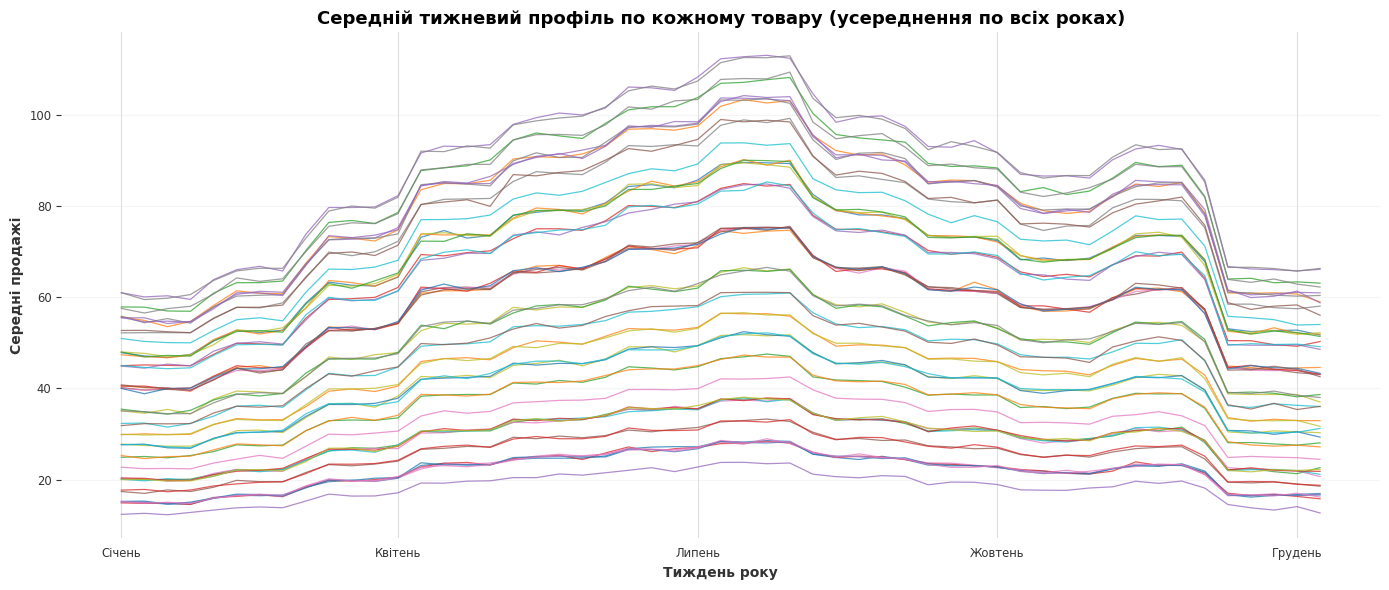

In [101]:
weekly_profile = (data.groupby([data.index.isocalendar().week, 'item'])['sales']
                    .mean()
                    .unstack('item'))

colors = sns.color_palette('tab10', len(weekly_profile.columns))

fig, ax = plt.subplots(figsize=(14, 6))
for col, color in zip(weekly_profile.columns, colors):
    ax.plot(weekly_profile.index, weekly_profile[col], color=color, linewidth=0.9, alpha=0.75)
ax.set_title('Середній тижневий профіль по кожному товару (усереднення по всіх роках)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Тиждень року')
ax.set_ylabel('Середні продажі')
ax.set_xticks([1, 13, 26, 39, 52])
ax.set_xticklabels(['Січень', 'Квітень', 'Липень', 'Жовтень', 'Грудень'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Загалом продажі різних товарів мають схожу динаміку та відрізняються переважно масштабом, що може свідчити про високу кореляцію між ними.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [14]:
data_additive = data[(data.item == 1) & (data.store == 1)].copy(deep=True)

# calculating the trend by smoothing the series with a yearly window of size 13
data_additive["trend"] = data_additive["sales"].rolling(window=12, center=True).mean()

# subtracting the trend from the data
data_additive["detrended"] = data_additive["sales"] - data_additive["trend"]

# calculating the seasonal component as the average value of the series after subtracting the trend
data_additive["month"] = data_additive.index.month
data_additive["seasonality"] = data_additive.groupby("month")["detrended"].transform("mean")

# calculating the residual as everything we couldn't explain with seasonality
data_additive["resid"] = data_additive["detrended"] - data_additive["seasonality"]

# what we got as a result
data_additive.head(15)

,store,item,sales,trend,detrended,month,seasonality,resid
date,,,,,,,,
2013-01-01,1,1,13,NaN,NaN,1,-0.077181,NaN
2013-01-02,1,1,11,NaN,NaN,1,-0.077181,NaN
2013-01-03,1,1,14,NaN,NaN,1,-0.077181,NaN
2013-01-04,1,1,13,NaN,NaN,1,-0.077181,NaN
2013-01-05,1,1,10,NaN,NaN,1,-0.077181,NaN
2013-01-06,1,1,12,NaN,NaN,1,-0.077181,NaN
2013-01-07,1,1,10,10.750000,-0.750000,1,-0.077181,-0.672819
2013-01-08,1,1,9,10.500000,-1.500000,1,-0.077181,-1.422819
2013-01-09,1,1,12,10.583333,1.416667,1,-0.077181,1.493848


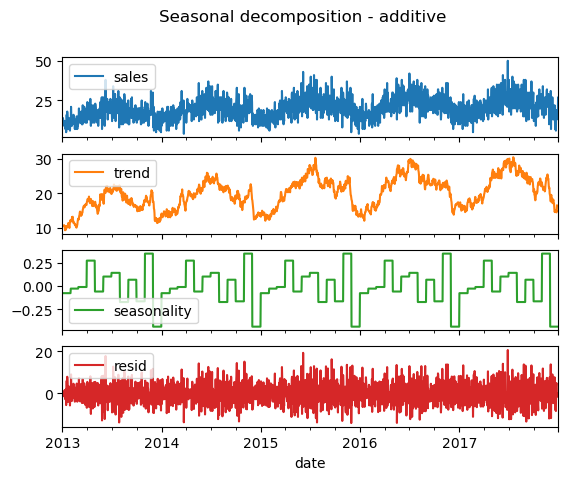

In [15]:
(
    data_additive
    .loc[:, ["sales", "trend", "seasonality", "resid"]]
    .plot(subplots=True, title="Seasonal decomposition - additive")
);

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [17]:
from darts import TimeSeries

# Loading data into darts, the index was automatically converted to a Darts index
series = TimeSeries.from_dataframe(data_additive, value_cols='sales')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

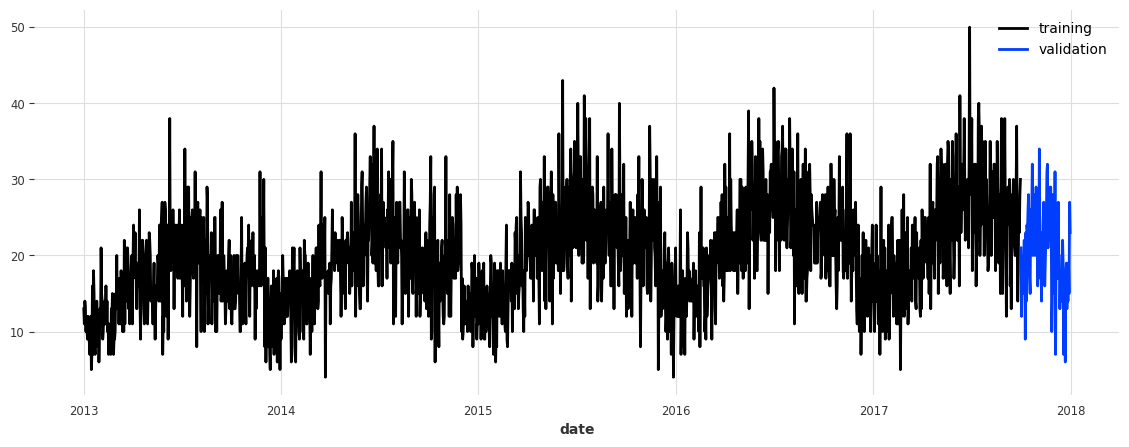

In [19]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
fig, ax = plt.subplots(figsize=(14, 5))
train.plot(label="training");
val.plot(label="validation");

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

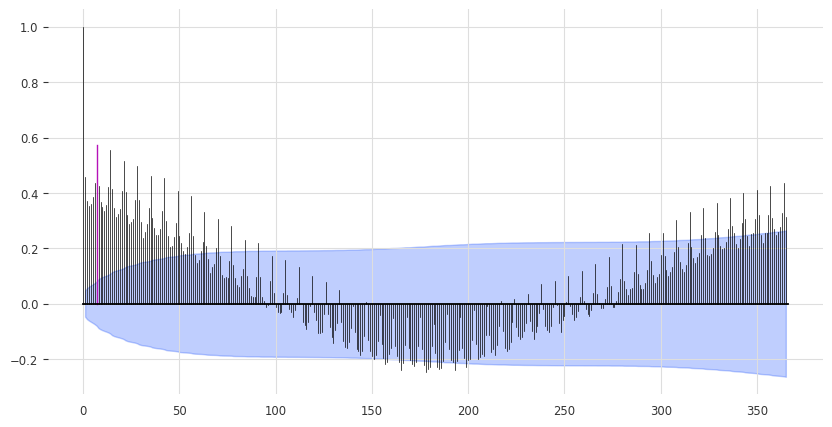

In [21]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=7, alpha=0.05, max_lag=365)

Аналіз автокореляційної функції показує, що найбільш значущими для прогнозування є короткі лаги (напр. 7), що відображають сильну залежність від недавніх значень. Особливо важливими є сезонні лаги близько 365 днів, що підтверджує річну сезонність у даних.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [24]:
for m in [2, 7, 30, 31, 364, 365]:
    is_seasonal, period = check_seasonality(train, m=m, max_lag=400, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 364.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

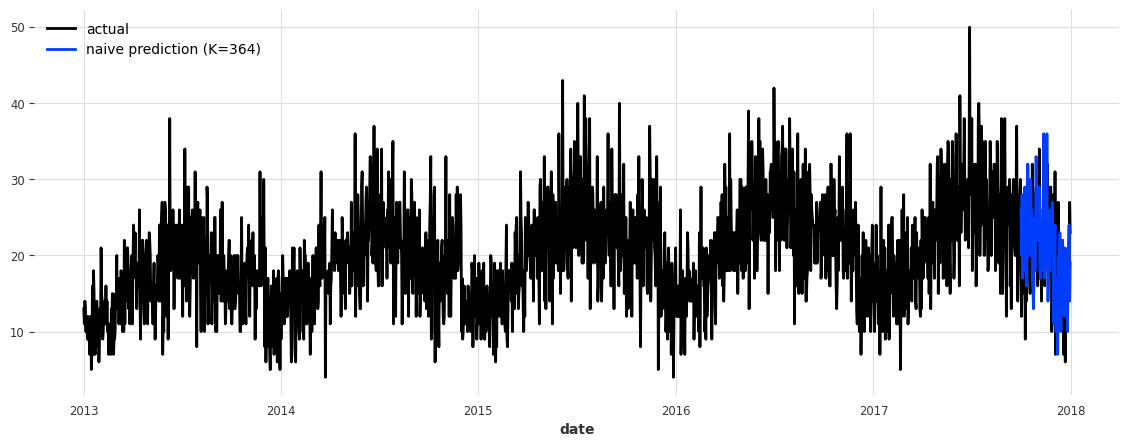

In [26]:
from darts.models import NaiveSeasonal

seasonal_model = NaiveSeasonal(K=364)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

fig, ax = plt.subplots(figsize=(14, 5))
series.plot(label="actual");
seasonal_forecast.plot(label="naive prediction (K=364)");

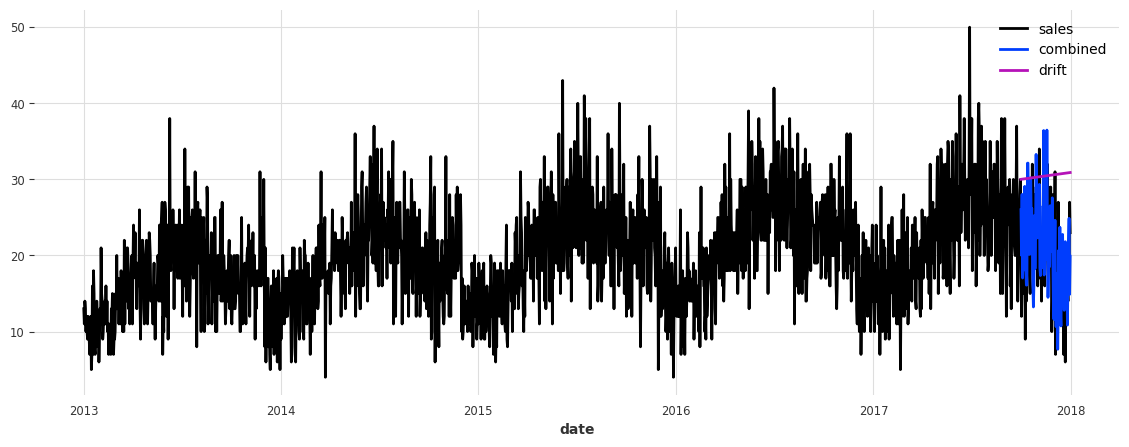

In [27]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

fig, ax = plt.subplots(figsize=(14, 5))
series.plot();
combined_forecast.plot(label="combined");
drift_forecast.plot(label="drift");

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [29]:
from darts.metrics import mape

mape_naive = mape(val, seasonal_forecast)
print(f"MAPE Naive: {mape_naive:.2f}%")

mape_naive_drift = mape(val, combined_forecast)
print(f"MAPE Naive (Seasonal+Drift): {mape_naive_drift:.2f}%")

MAPE Naive: 31.79%
MAPE Naive (Seasonal+Drift): 32.21%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [31]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

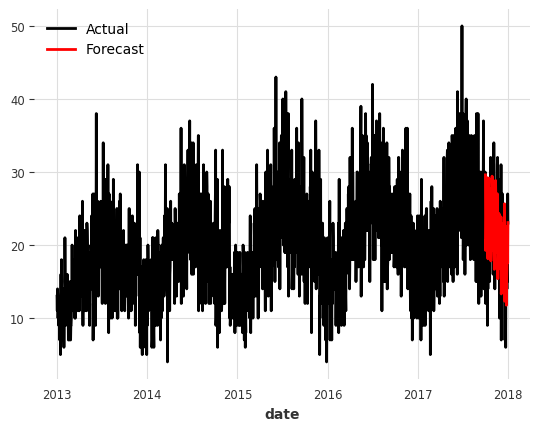

model XGBRegressor: 26.47%


In [32]:
def enrich_with_date_features(data):
  # Feature Extraction
  # data["hour"] = data['date'].dt.hour
  # data["dayofweek"] = data['date'].dt.dayofweek
  data["quarter"] = data['date'].dt.quarter
  # data["month"] = data['date'].dt.month
  data["year"] = data['date'].dt.year
  data["dayofyear"] = data['date'].dt.dayofyear
  data["sin_day"] = np.sin(data["dayofyear"])
  data["cos_day"] = np.cos(data["dayofyear"])
  # data["dayofmonth"] = data['date'].dt.day
  return data

# Adding date features
train_transformed = enrich_with_date_features(train.to_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.to_dataframe().reset_index())

# Scaling data
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)

# Building XGBoost model
model = XGBModel(
    lags=364,  # Using the last 364 observations for forecasting
    output_chunk_length=1,  # Forecasting 1 step ahead
    n_estimators=100,  # Number of trees in the model
    max_depth=3,  # Maximum depth of each tree
    learning_rate=0.1,  # Learning rate
    subsample=0.8,  # Fraction of data for random sampling of each tree
    colsample_bytree=0.8  # Fraction of features used for each tree
)

# Training the model
model.fit(train_transformed)
pred = model.predict(364)
forecast = scaler.inverse_transform(model.predict(len(val)))
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

xgb = mape(val, forecast)
print(f"model XGBRegressor: {xgb:.2f}%")

Модель XGBRegressor показала покращення якості прогнозу порівняно з наївним підходом, що свідчить про здатність моделі враховувати залежності в даних

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [34]:
from darts.models import ExponentialSmoothing

In [35]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

def fit_eval_model(model):
    model.fit(train)
    forecast = model.predict(len(val))
    eval_forecast(model, val, forecast)


fit_eval_model(ExponentialSmoothing(seasonal_periods=364))

model ExponentialSmoothing(seasonal_periods=364) obtains MAPE: 27.21%


Модель Exponential Smoothing показала результат близький до результату XGBRegressor (26.47%). Незначна різниця свідчить про те, що основна структура даних визначається трендом та сезонністю, які ефективно моделюються й простішими методами.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [37]:
from darts.models import ARIMA

# Building and training the ARIMA model
model = ARIMA(p=2, d=1, q=2, seasonal_order=(1, 1, 1, 7))
fit_eval_model(model)

model ARIMA(p=2, q=2, seasonal_order=(1, 1, 1, 7)) obtains MAPE: 38.85%


Модель ARIMA враховує лише тижневу сезональність, адже для seasonal_order=(1, 1, 1, 364) вона надто повільна. Тижнева ж сезонність для даної моделі не показує покращення порівняно з наївною моделлю

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [39]:
from darts.models import AutoARIMA
fit_eval_model(AutoARIMA())

model AutoARIMA() obtains MAPE: 40.29%


In [40]:
model = AutoARIMA()
model.fit(train)
display(fit_eval_model(AutoARIMA()))

model AutoARIMA() obtains MAPE: 40.29%


None

AutoARIMA() не покращила результат ARIMA(), що показує, що дана модель не підходить для даного датасету 

14. Натренуйте модель Prophet та зробіть висновок про її якість.

20:54:07 - cmdstanpy - INFO - Chain [1] start processing
20:54:07 - cmdstanpy - INFO - Chain [1] done processing


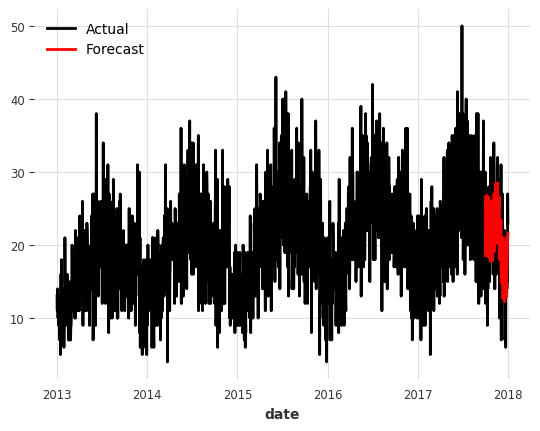

20:54:07 - cmdstanpy - INFO - Chain [1] start processing
20:54:07 - cmdstanpy - INFO - Chain [1] done processing


model Prophet() obtains MAPE: 23.82%


In [42]:
from darts.models import Prophet

# Building and training the Prophet model
model = Prophet()
model.fit(train)

# Forecasting
forecast = model.predict(len(val))

# Visualizing the results
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

fit_eval_model(Prophet())

Модель Prophet показала найкращий результат серед розглянутих підходів, суттєво перевершивши XGBRegressor

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 5.2 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
5.2 K     Trainable params
0         Non-trainable params
5.2 K     Total params
0.021     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

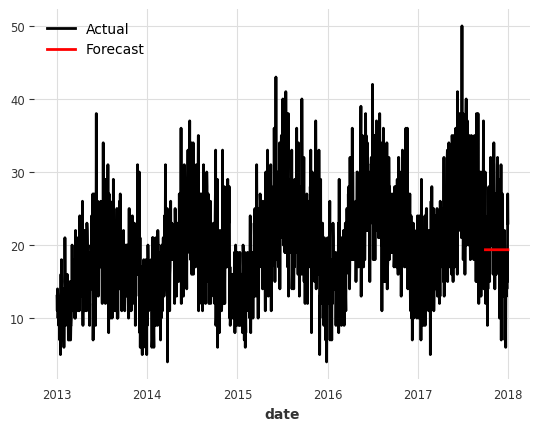

In [68]:
from darts.models import RNNModel
from pytorch_lightning.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="train_loss",
    patience=5,
    min_delta=0.001,
    mode="min"
)
# Building and training the LSTM model
model = RNNModel(
    model='LSTM',
    input_chunk_length=364,
    hidden_dim=20,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=32,
    n_epochs=50,
    optimizer_kwargs={"lr": 1e-3},
    training_length=364,
    random_state=42,
    force_reset=True,
    log_tensorboard=True,
    pl_trainer_kwargs={"callbacks": [early_stopping]}
)
model.fit(train)

# Forecasting
forecast = model.predict(len(val))

# Visualizing the results
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [70]:
mape_rnn = mape(val, forecast)
print(f"MAPE RNN: {mape_rnn:.2f}%")

MAPE RNN: 27.60%


Модель RNN показала результат, який значно поступається Prophet. Це свідчить про те, що використання складних нейронних мереж не дає переваг для даного набору даних

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [78]:
# our best model

model = Prophet()
model.fit(train)
forecast = model.predict(len(val))
eval_forecast(model, val, forecast);

21:54:55 - cmdstanpy - INFO - Chain [1] start processing
21:54:56 - cmdstanpy - INFO - Chain [1] done processing


model Prophet() obtains MAPE: 23.82%


historical forecasts:   0%|          | 0/86 [00:00<?, ?it/s]

21:57:29 - cmdstanpy - INFO - Chain [1] start processing
21:57:29 - cmdstanpy - INFO - Chain [1] done processing
21:57:29 - cmdstanpy - INFO - Chain [1] start processing
21:57:30 - cmdstanpy - INFO - Chain [1] done processing
21:57:30 - cmdstanpy - INFO - Chain [1] start processing
21:57:30 - cmdstanpy - INFO - Chain [1] done processing
21:57:30 - cmdstanpy - INFO - Chain [1] start processing
21:57:30 - cmdstanpy - INFO - Chain [1] done processing
21:57:30 - cmdstanpy - INFO - Chain [1] start processing
21:57:30 - cmdstanpy - INFO - Chain [1] done processing
21:57:31 - cmdstanpy - INFO - Chain [1] start processing
21:57:31 - cmdstanpy - INFO - Chain [1] done processing
21:57:31 - cmdstanpy - INFO - Chain [1] start processing
21:57:31 - cmdstanpy - INFO - Chain [1] done processing
21:57:31 - cmdstanpy - INFO - Chain [1] start processing
21:57:31 - cmdstanpy - INFO - Chain [1] done processing
21:57:31 - cmdstanpy - INFO - Chain [1] start processing
21:57:31 - cmdstanpy - INFO - Chain [1]

MAPE = 23.04%


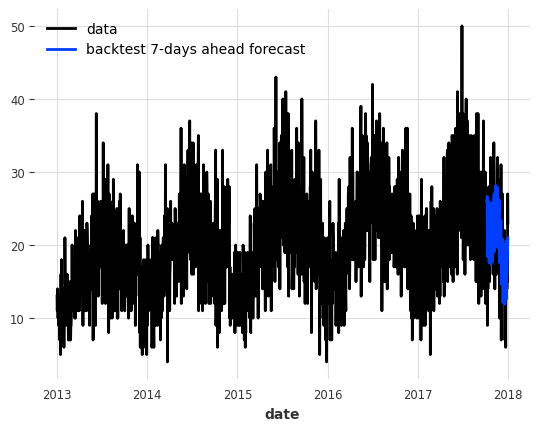

In [81]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-10-01"),  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 7,
    "verbose": True,
}

historical_fcast = model.historical_forecasts(last_points_only=True, **hfc_params)

series.plot(label="data")
historical_fcast.plot(label="backtest 7-days ahead forecast")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

historical forecasts:   0%|          | 0/86 [00:00<?, ?it/s]

21:59:46 - cmdstanpy - INFO - Chain [1] start processing
21:59:47 - cmdstanpy - INFO - Chain [1] done processing
21:59:47 - cmdstanpy - INFO - Chain [1] start processing
21:59:47 - cmdstanpy - INFO - Chain [1] done processing
21:59:47 - cmdstanpy - INFO - Chain [1] start processing
21:59:47 - cmdstanpy - INFO - Chain [1] done processing
21:59:47 - cmdstanpy - INFO - Chain [1] start processing
21:59:47 - cmdstanpy - INFO - Chain [1] done processing
21:59:47 - cmdstanpy - INFO - Chain [1] start processing
21:59:48 - cmdstanpy - INFO - Chain [1] done processing
21:59:48 - cmdstanpy - INFO - Chain [1] start processing
21:59:48 - cmdstanpy - INFO - Chain [1] done processing
21:59:48 - cmdstanpy - INFO - Chain [1] start processing
21:59:48 - cmdstanpy - INFO - Chain [1] done processing
21:59:48 - cmdstanpy - INFO - Chain [1] start processing
21:59:48 - cmdstanpy - INFO - Chain [1] done processing
21:59:49 - cmdstanpy - INFO - Chain [1] start processing
21:59:49 - cmdstanpy - INFO - Chain [1]

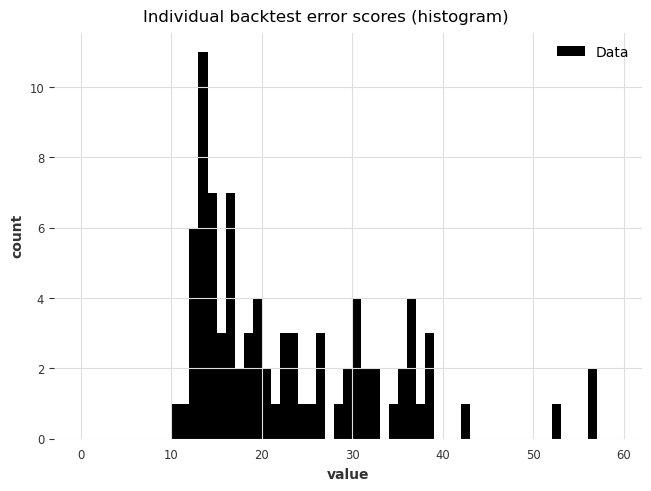

In [88]:
raw_errors = model.backtest(metric=mape, reduction=None, last_points_only=False, stride=1, **hfc_params)

from darts.utils.statistics import plot_hist

plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Individual backtest error scores (histogram)",
)

Розподіл помилок прогнозу є асиметричним, що свідчить про наявність окремих періодів із суттєвими відхиленнями моделі. Основна частина помилок зосереджена в діапазоні 12–25%, що вказує на загалом стабільну якість прогнозу.

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Загалом в силу того, що для даного датасету динаміка кожного окремого item та store схожа між собою, я б не виділяв окремі моделі прогнозу для різних item чи store. Загалом можна вибрати середнє значення продажів і на основі нього зробити модель прогнозу для всього датасету.

Для даного датасету досить непогано показала себе модель Prophet(), тому я б зробив її основною з можливим подальшим коригуванням на нових даних, як показано в бектесті